# **🚴‍♀️ Проект спринта: Нелинейные модели против сочинской погоды**

Компания **BikeSochi**, оператор городского велопроката в Сочи, обратилась за помощью в улучшении системы прогнозирования почасового спроса на велосипеды.

До этого аналитики компании использовали простую линейную регрессию — одну из самых базовых моделей машинного обучения.

Однако её прогнозы часто ошибались:



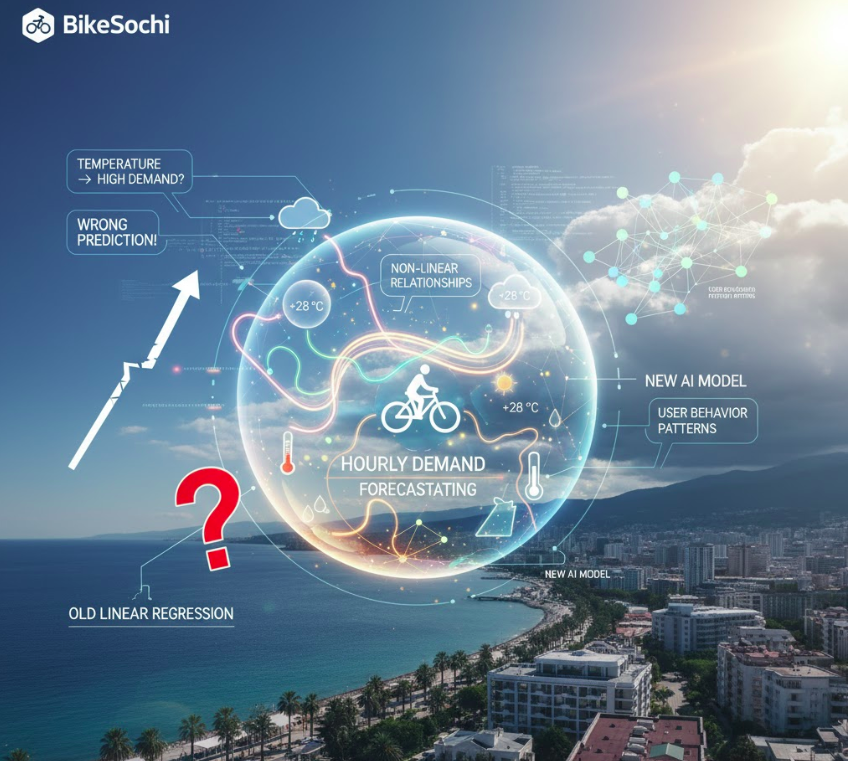

> «Модель видела, что температура выросла — и сразу предсказывала высокий спрос.
Но не понимала, что +28 °C под палящим солнцем и +28 °C после дождя — это две совсем разные ситуации.»

Погода в Сочи меняется быстро, и влияние факторов — нелинейное: температура, влажность, солнечная радиация, осадки влияют на поведение людей не по простым прямым зависимостям.



---



В рамках этого проекта вы выступаете в роли аналитиков компании **BikeSochi, которые должны предложить новую, более гибкую модель прогнозирования.**

**В этом проекте вы:**

1. Изучите предоставленную компанией baseline-модель (линейную регрессию);

2. Обучите новые модели — K-ближайших соседей (KNN) и решающее дерево (Decision Tree);

3. Проведёте подбор гиперпараметров с помощью библиотеки Optuna;

4. Сравните результаты всех подходов, выберете наилучший и аргументируете свой выбор.

Дополнительно: Реализуете собственный класс-трансформер и интегрируете его в пайплайн.


**К концу проекта у вас будет:**

— улучшенная модель прогноза почасового спроса на велосипеды в Сочи;

— отчёт с метриками и сравнением подходов;

— сохранённый пайплайн лучшей модели.



---



# **Часть 1: Базовая модель**

В этой части вы познакомитесь с тем, как работает baseline-модель, которую использовала компания BikeSochi до внедрения улучшенной версии.

Компания предоставила вам:

— `models/baseline_linear_regression_pipeline.joblib` — готовый обученный пайплайн (без исходного кода);

— краткое описание того, как он был устроен;

— тренировочную и тестовую выборки, которые можно использовать для оценки модели.

Это значит, что вам не нужно обучать эту модель заново — вы просто загружаете её и проверяете качество (например, на метриках RMSE, MAE, R²).

**Совет:**
1. Убедитесь, что у вас есть `models/baseline_linear_regression_pipeline.joblib`, `data/raw/ds_s14_train_data.csv` и `data/raw/ds_s14_test_data.csv`.

2. Разделите тестовый набор на признаки (X) и целевую переменную Rented Bike Count.

3. Загрузите `.joblib` файл — это готовый пайплайн, который сам обрабатывает данные и делает предсказания. Модель автоматически применяет трансформации и возвращает прогнозы.

4. Посчитайте RMSE, MAE и R², эти результаты нужны для оценки ваших улучшенных моделей в дальнейшей работе.

# **Часть 2: Улучшение модели — KNN и Decision Tree**

Ваша задача — предложить более гибкую модель прогноза спроса на велосипеды, которая учитывает нюансы сочинской погоды и поведение клиентов.

Вы будете экспериментировать с K-ближайшими соседями (KNN) и решающим деревом (Decision Tree), использовать подбор гиперпараметров с Optuna и внедрять кастомные трансформеры для новых признаков.

**Шаг 1: Изучение постановки задачи:**

Проведите EDA (Exploratory Data Analysis):
1. Посмотрите на распределение целевой переменной Rented Bike Count. Есть ли выбросы или сильные сезонные колебания?
2. Постройте графики зависимости спроса от температуры, осадков, солнечной радиации.
3. Сравните спрос в разные сезоны и праздничные дни.
4. Проверьте корреляции между признаками и целевой переменной.

**Совет:**

Не нужно сразу всё усложнять. Начните с базовых графиков и описательной статистики.



---



**Шаг 2: Разделение данных на тренировочную и валидационную выборки**

> У вас есть доступ к тренировочной и тестовой выборкам.

Тестовый набор используется для финальной оценки модели после тренировки и подбора гиперпараметров.

Вы тренируетесь на тренировочных данных и оцениваете качество через валидацию.

---



**Шаг 3: Обучение новых моделей**

> Теперь пора «проверить, насколько далеко уедут модели» — KNN и Decision Tree могут уловить нелинейные зависимости, недоступные линейной регрессии.

Что нужно сделать:
1. Подготовьте пайплайн для каждой модели:
    * Предобработка данных.
    * Модель (KNN или Decision Tree).
4. Настройте базовые параметры моделей (например, n_neighbors для KNN, max_depth для дерева).

**Совет:**

Начинайте с базовых параметров, чтобы убедиться, что пайплайн работает. Оптимизацию параметров делаем на следующем шаге.

---



**Шаг 4: Подбор гиперпараметров с Optuna**

> Компания хочет точную модель. Optuna поможет найти лучшие параметры для KNN и дерева, чтобы снизить ошибки прогноза.

Что нужно сделать:
1. Определите функцию цели для Optuna.

2. Настройте диапазоны гиперпараметров.

3. Запустите оптимизацию и сохраните лучшие параметры.

**Совет:**

Не бойтесь экспериментировать с небольшими диапазонами сначала, а потом расширять, если модель «не уловила» зависимости.

---



**Шаг 5: Кросс-валидация новых моделей**

Что нужно сделать:
1. Проведите кросс-валидацию для KNN и Decision Tree с оптимальными гиперпараметрами.
2. Сравните метрики с baseline-моделью.
3. Определите, какая модель показывает лучшие результаты на тренировочной выборке.

**Совет:**

Используйте визуализации (bar plot, box plot), чтобы увидеть разброс метрик и стабильность моделей.


---



**Шаг 6: Составление отчёта по моделям**

Что нужно сделать:
1. Составьте таблицу с метриками: baseline, KNN, Decision Tree.
2. Добавьте визуализацию, если необходимо: bar plot или box plot по RMSE/MAE.

Подготовьте выводы:
1. Какая модель лучше справляется с прогнозом?
2. Какие признаки, по вашему мнению, особенно важны?


**Совет:**

Старайтесь объяснить результаты в бизнес-контексте: «Эта модель лучше реагирует на дождь», «Температура и влажность сильно влияют на спрос в пиковые часы».

---



**Шаг 7: Сохранение модели и отчёта**

Что нужно сделать:
1. Выберите финальную, наилучшую модель и оцените её качество на тестовой выборке, чтобы понять, насколько она прогнозирует реальные данные.
2. Подготовьте ноутбук с кодом и комментариями: включите результаты всех экспериментов, метрики моделей, визуализации, а также обоснование выбора финальной модели.

**Совет:**

Документируйте каждый шаг: почему выбраны те или иные гиперпараметры и подходы. В реальной бизнес-задаче это помогает коллегам и руководству понимать решения и доверять модели.

---



**Опционально: Реализация кастомного трансформера**

> Простые признаки вроде температуры или влажности не всегда отражают реальную ситуацию.
Чтобы модель могла лучше прогнозировать спрос на велосипеды, можно создавать новые признаки, которые учитывают особенности погоды или взаимодействия факторов.

Что нужно сделать:
1. Реализуйте класс с методами fit и transform.
2. Вставьте его в пайплайн перед моделью.
3. Проверьте, что трансформер корректно работает с тренировочными данными.

**Совет:**
Если вы решите реализовать трансформер, начинайте с простых комбинаций признаков, чтобы не усложнять модель слишком рано.


---



# **Авторское решение**